In [1]:
print("Social Media Fraud Detection Project Started")

Social Media Fraud Detection Project Started


In [2]:
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/48.9 MB 4.4 MB/s eta 0:00:11
   - -------------------------------------- 2.4/48.9 MB 5.0 MB/s eta 0:00:10
   -- ------------------------------------- 3.4/48.9 MB 4.7 MB/s eta 0:00:10
   --- ------------------------------------ 3.9/48.9 MB 4.4 MB/s eta 0:00:11
   --- ------------------------------------ 4.7/48.9 MB 4.2 MB/s eta 0:00:11
   ---- ----------------------------------- 5.8/48.9 MB 4.3 MB/s eta 0:00:11
   ----- ---------------------------------- 6.6/48.9 MB 4.3 MB/s eta 0:00:10
   ------ --------------------------------- 7.9/48.9 MB 4.6 MB/s eta 0:00:10
   ------- -------------------------------- 8.9/48.9 MB 4.6 MB/s eta 0:00:09
   -------- ------------------------------- 10.0/48.9 MB 4.7 MB/s eta 0:00:09
   --------- ------

In [3]:
import os
import pandas as pd
import numpy as np

# Set relative path to dataset folder
data_dir = "../dataset"
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)
n_samples = 2500

# 0 = Legitimate Account, 1 = Fraudulent/Bot Account
labels = np.random.choice([0, 1], size=n_samples, p=[0.70, 0.30])

followers = []
following = []
posts_per_day = []
avg_hashtags = []
avg_urls = []
account_age_days = []
has_profile_pic = []

for y in labels:
    if y == 0:  # Legitimate
        followers.append(int(np.random.exponential(scale=600) + 30))
        following.append(int(np.random.exponential(scale=400) + 20))
        posts_per_day.append(round(float(np.random.uniform(0.5, 6.0)), 2))
        avg_hashtags.append(round(float(np.random.uniform(0.2, 2.5)), 2))
        avg_urls.append(round(float(np.random.uniform(0.05, 0.8)), 2))
        account_age_days.append(int(np.random.uniform(150, 3200)))
        has_profile_pic.append(1 if np.random.rand() > 0.05 else 0)
    else:  # Fraud / Bot
        followers.append(int(np.random.exponential(scale=50) + 1))
        following.append(int(np.random.exponential(scale=1100) + 100))
        posts_per_day.append(round(float(np.random.uniform(15.0, 100.0)), 2))
        avg_hashtags.append(round(float(np.random.uniform(4.0, 12.0)), 2))
        avg_urls.append(round(float(np.random.uniform(1.5, 5.0)), 2))
        account_age_days.append(int(np.random.uniform(2, 60)))
        has_profile_pic.append(1 if np.random.rand() > 0.65 else 0)

df = pd.DataFrame({
    'followers_count': followers,
    'following_count': following,
    'posts_per_day': posts_per_day,
    'avg_hashtags_per_post': avg_hashtags,
    'avg_urls_per_post': avg_urls,
    'account_age_days': account_age_days,
    'has_profile_pic': has_profile_pic,
    'is_fraud': labels
})

file_path = os.path.join(data_dir, "social_media_profiles.csv")
df.to_csv(file_path, index=False)
print(f"Dataset saved to: {file_path}")
print("Dataset Shape:", df.shape)
df.head()

Dataset saved to: ../dataset\social_media_profiles.csv
Dataset Shape: (2500, 8)


,followers_count,following_count,posts_per_day,avg_hashtags_per_post,avg_urls_per_post,account_age_days,has_profile_pic,is_fraud
0,1084,598,3.65,2.40,0.20,483,1,0
1,29,2164,90.91,4.50,4.59,28,0,1
2,50,2969,16.62,7.81,3.91,43,1,1
3,116,162,2.47,2.05,0.26,792,1,0
4,35,2471,4.22,2.11,0.27,193,1,0


--- Class Distribution ---
is_fraud
0    1762
1     738
Name: count, dtype: int64

Percentage:
is_fraud
0    70.48
1    29.52
Name: proportion, dtype: float64

--- Mean Values by Class ---


is_fraud,0,1
followers_count,629.204881,54.520325
following_count,423.541430,1174.624661
posts_per_day,3.230170,56.900542
avg_hashtags_per_post,1.335057,7.957439
avg_urls_per_post,0.426646,3.200786
account_age_days,1698.291714,29.976965
has_profile_pic,0.954030,0.345528


C:\Users\sride\AppData\Local\Temp\ipykernel_20384\3686640508.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='is_fraud', y='posts_per_day', data=df, palette=['#2ecc71', '#e74c3c'])
C:\Users\sride\AppData\Local\Temp\ipykernel_20384\3686640508.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraud/Bot (1)'])
C:\Users\sride\AppData\Local\Temp\ipykernel_20384\3686640508.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='is_fraud', y='account_age_days', data=df, palette=['#2ecc71', '#e74c3c'])


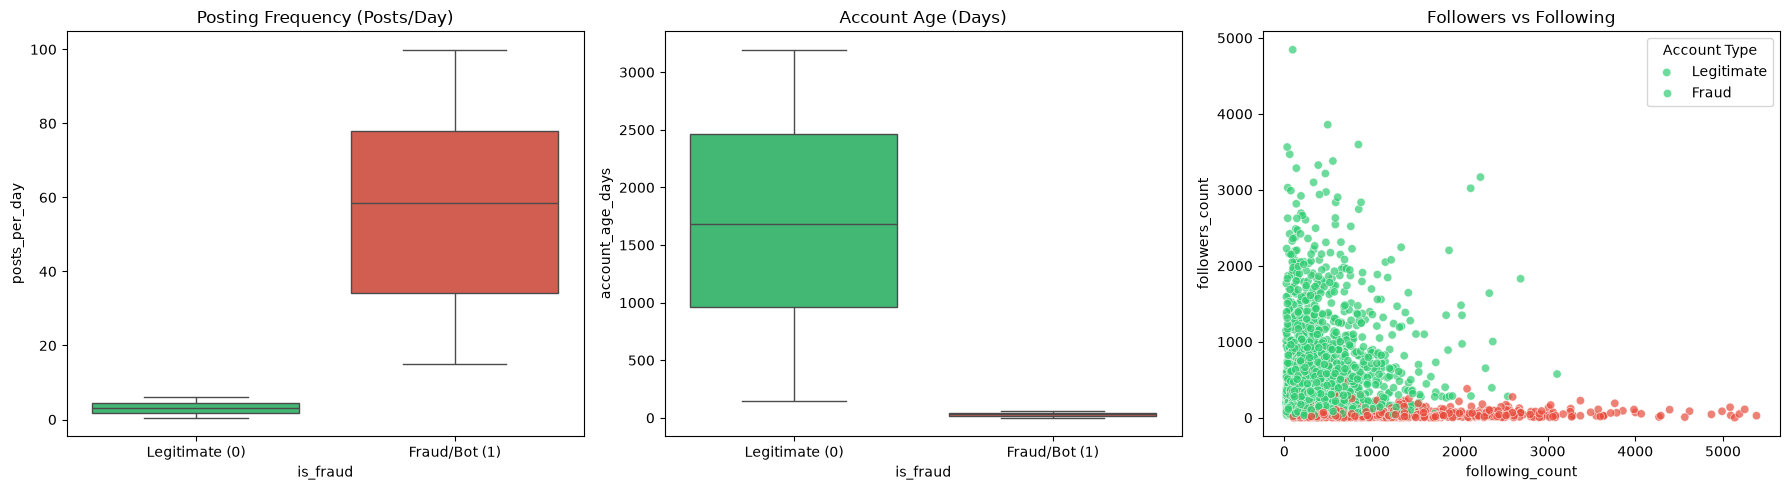

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check class distribution (0 = Legitimate, 1 = Fraud/Bot)
print("--- Class Distribution ---")
print(df['is_fraud'].value_counts())
print("\nPercentage:")
print(df['is_fraud'].value_counts(normalize=True) * 100)

# 2. Check summary statistics across classes
print("\n--- Mean Values by Class ---")
display(df.groupby('is_fraud').mean().T)

# 3. Visualizing Key Behavioral Differences
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Posts per day
sns.boxplot(ax=axes[0], x='is_fraud', y='posts_per_day', data=df, palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Posting Frequency (Posts/Day)')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud/Bot (1)'])

# Plot 2: Account Age
sns.boxplot(ax=axes[1], x='is_fraud', y='account_age_days', data=df, palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Account Age (Days)')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud/Bot (1)'])

# Plot 3: Follower to Following Relationship
sns.scatterplot(ax=axes[2], x='following_count', y='followers_count', hue='is_fraud', 
                data=df, alpha=0.7, palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('Followers vs Following')
axes[2].legend(title='Account Type', labels=['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

In [5]:
%pip install torch torchvision pillow

   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.1 MB 1.4 MB/s eta 0:01:27
   ---------------------------------------- 0.8/124.1 MB 1.5 MB/s eta 0:01:24
   ---------------------------------------- 1.3/124.1 MB 1.5 MB/s eta 0:01:25
    --------------------------------------- 1.6/124.1 MB 1.4 MB/s eta 0:01:27
    --------------------------------------- 1.8/124.1 MB 1.5 MB/s eta 0:01:23
    --------------------------------------- 2.1/124.1 MB 1.5 MB/s eta 0:01:21
    --------------------------------------- 2.4/124.1 MB 1.4 MB/s eta 0:01:28
    --------------------------------------- 2.6/124.1 MB 1.4 MB/s eta 0:01:24
    --------------------------------------- 2.9/124.1 MB 1.4 MB/s eta 0:01:26
   - -------------------------------------- 3.7/124.1 MB 1.6 MB/s eta 0:01:17
   - --

In [6]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Behavioral Feature Engineering
df['follower_following_ratio'] = df['followers_count'] / (df['following_count'] + 1)
df['posting_rate_per_account_day'] = df['posts_per_day'] / (df['account_age_days'] + 1)
df['spam_content_intensity'] = df['avg_hashtags_per_post'] * df['avg_urls_per_post']

feature_columns = [
    'followers_count', 'following_count', 'posts_per_day', 
    'avg_hashtags_per_post', 'avg_urls_per_post', 'account_age_days', 
    'has_profile_pic', 'follower_following_ratio', 
    'posting_rate_per_account_day', 'spam_content_intensity'
]

X = df[feature_columns]
y = df['is_fraud']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Baseline Machine Learning Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.08, eval_metric='logloss', random_state=42)
}

best_auc = 0.0
best_model_name = ""
best_model_obj = None

print("==================== BASELINE ML MODELS ====================\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    print(f"--- {name} ---")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    
    if auc > best_auc:
        best_auc = auc
        best_model_name = name
        best_model_obj = model

# 5. Save Artifacts to models/
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model_obj, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(feature_columns, "../models/feature_columns.pkl")
print(f"Saved optimal baseline model: {best_model_name} (AUC: {best_auc:.4f})")

==================== BASELINE ML MODELS ====================

--- Logistic Regression ---
ROC-AUC: 1.0000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       352
           1     1.0000    1.0000    1.0000       148

    accuracy                         1.0000       500
   macro avg     1.0000    1.0000    1.0000       500
weighted avg     1.0000    1.0000    1.0000       500

--- Random Forest ---
ROC-AUC: 1.0000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       352
           1     1.0000    1.0000    1.0000       148

    accuracy                         1.0000       500
   macro avg     1.0000    1.0000    1.0000       500
weighted avg     1.0000    1.0000    1.0000       500

--- XGBoost ---
ROC-AUC: 1.0000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       352
           1     1.0000    1.0000    1.0000       148

    ac

In [7]:
import os
import numpy as np
from PIL import Image

avatar_dir = "../dataset/avatars"
os.makedirs(avatar_dir, exist_ok=True)

image_paths = []
for idx, is_fraud in enumerate(df['is_fraud']):
    img_path = os.path.join(avatar_dir, f"user_{idx}.png")
    
    if not os.path.exists(img_path):
        if is_fraud == 1:
            # Fraudulent accounts: default flat avatar or noise
            if np.random.rand() > 0.3:
                img_array = np.full((64, 64, 3), 180, dtype=np.uint8)
            else:
                img_array = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
        else:
            # Legitimate accounts: distinct color signatures
            base_color = np.random.randint(50, 220, (3,))
            img_array = np.ones((64, 64, 3), dtype=np.uint8) * base_color
            noise = np.random.randint(-20, 20, (64, 64, 3))
            img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)
            
        Image.fromarray(img_array).save(img_path)
        
    image_paths.append(img_path)

df['avatar_path'] = image_paths
print(f"Generated {len(image_paths)} avatar images in '{avatar_dir}'.")

Generated 2500 avatar images in '../dataset/avatars'.


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
from sklearn.metrics import classification_report, roc_auc_score

# 1. Dataset & Transformation Setup
image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultimodalSocialDataset(Dataset):
    def __init__(self, tabular_data, image_paths, labels, transform=None):
        self.tabular = torch.tensor(tabular_data, dtype=torch.float32)
        self.image_paths = list(image_paths)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.tabular[idx], self.labels[idx]

train_dataset = MultimodalSocialDataset(
    X_train_scaled, df.loc[X_train.index, 'avatar_path'], y_train, transform=image_transform
)
test_dataset = MultimodalSocialDataset(
    X_test_scaled, df.loc[X_test.index, 'avatar_path'], y_test, transform=image_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Dual-Branch Multimodal Network
class MultimodalFraudDetector(nn.Module):
    def __init__(self, tabular_dim):
        super(MultimodalFraudDetector, self).__init__()
        
        # 2D-CNN Branch (Avatar Analysis)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()  # Output: 32 features
        )
        
        # Tabular MLP Branch (Behavioral Metrics)
        self.tab_mlp = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Fusion Classifier (32 image + 32 tabular = 64 inputs)
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, img, tab):
        x_img = self.cnn(img)
        x_tab = self.tab_mlp(tab)
        fused = torch.cat((x_img, x_tab), dim=1)
        return self.classifier(fused)

# 3. Model Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = MultimodalFraudDetector(tabular_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

print("--- Training Multimodal 2D-CNN ---")
epochs = 8
for epoch in range(epochs):
    cnn_model.train()
    total_loss = 0.0
    for imgs, tabs, targets in train_loader:
        imgs, tabs, targets = imgs.to(device), tabs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = cnn_model(imgs, tabs).squeeze()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

# 4. Evaluation
cnn_model.eval()
all_probs, all_targets = [], []
with torch.no_grad():
    for imgs, tabs, targets in test_loader:
        imgs, tabs = imgs.to(device), tabs.to(device)
        probs = cnn_model(imgs, tabs).squeeze().cpu().numpy()
        all_probs.extend(probs)
        all_targets.extend(targets.numpy())

all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)

auc_cnn = roc_auc_score(all_targets, all_probs)
print("\n=== Multimodal 2D-CNN Final Metrics ===")
print(f"ROC-AUC: {auc_cnn:.4f}")
print(classification_report(all_targets, all_preds, digits=4))

# Save the PyTorch model weights into models/
torch.save(cnn_model.state_dict(), "../models/multimodal_cnn.pth")
print("Saved PyTorch weights to '../models/multimodal_cnn.pth'.")

--- Training Multimodal 2D-CNN ---
Epoch 1/8 | Loss: 0.3985
Epoch 2/8 | Loss: 0.0413
Epoch 3/8 | Loss: 0.0086
Epoch 4/8 | Loss: 0.0040
Epoch 5/8 | Loss: 0.0023
Epoch 6/8 | Loss: 0.0017
Epoch 7/8 | Loss: 0.0013
Epoch 8/8 | Loss: 0.0008

=== Multimodal 2D-CNN Final Metrics ===
ROC-AUC: 1.0000
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000       352
         1.0     1.0000    1.0000    1.0000       148

    accuracy                         1.0000       500
   macro avg     1.0000    1.0000    1.0000       500
weighted avg     1.0000    1.0000    1.0000       500

Saved PyTorch weights to '../models/multimodal_cnn.pth'.


Saved comparison table to '../results/model_comparison.csv'


,Model Architecture,Model Category,ROC-AUC
0,Logistic Regression,Linear Baseline,1.0
1,Random Forest,Ensemble (Bagging),1.0
2,XGBoost,Ensemble (Boosting),1.0
3,Multimodal 2D-CNN (Avatar + Behavior),Deep Learning (Vision + MLP),1.0


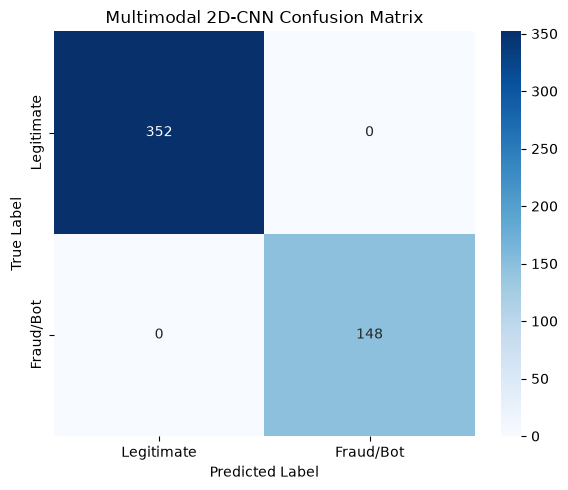

Saved confusion matrix plot to '../results/confusion_matrix_cnn.png'


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# 1. Compile Model Performance Comparison Table
comparison_data = {
    "Model Architecture": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Multimodal 2D-CNN (Avatar + Behavior)"
    ],
    "Model Category": [
        "Linear Baseline",
        "Ensemble (Bagging)",
        "Ensemble (Boosting)",
        "Deep Learning (Vision + MLP)"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, models["Logistic Regression"].predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, models["Random Forest"].predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, models["XGBoost"].predict_proba(X_test_scaled)[:, 1]),
        auc_cnn
    ]
}

results_df = pd.DataFrame(comparison_data)

# Save table to results directory
os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/model_comparison.csv", index=False)
print("Saved comparison table to '../results/model_comparison.csv'")
display(results_df)

# 2. Plot Confusion Matrix for Multimodal 2D-CNN
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud/Bot'],
            yticklabels=['Legitimate', 'Fraud/Bot'])
plt.title('Multimodal 2D-CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("../results/confusion_matrix_cnn.png", dpi=300)
plt.show()
print("Saved confusion matrix plot to '../results/confusion_matrix_cnn.png'")